# Mexico Earthquake Analysis (EDA) — Phase 1

This project is part of a geospatial analysis series focused on processing, cleaning, and visualizing seismic activity in Mexico. The goal of this first phase is to build a solid **data pipeline** by consuming an external API and preparing the data for exploratory analysis.

### Project Objectives

* **Data Ingestion:** Fetch raw seismic data from the USGS API.
* **Data Processing:** Convert complex JSON structures into clean pandas DataFrames.
* **EDA:** Analyze frequency, magnitude distributions, and regional patterns.

### Pipeline Structure

1. **Step 1:** Data Acquisition (`scripts/fetch_earthquakes.py`)
2. **Step 2:** Data Cleaning and Formatting (`scripts/process_data.py`)
3. **Step 3:** Exploratory Data Analysis (Visualizations)

---

## Step 1: Data Acquisition

In this section, we connect to the **USGS Earthquake Hazards Program API**. We define a bounding box to filter events specifically within Mexican territory and save the raw response as a `.json` file to maintain a professional data workflow.


---

## Step 2: Data Processing and Cleaning

In this stage, we transform the raw JSON data into a structured **pandas DataFrame**. This process, often called **ETL (Extract, Transform, Load)**, is critical to ensure our analysis is accurate and efficient.

### Tasks:

* **JSON Parsing:** Extract relevant fields from the nested USGS GeoJSON structure.
* **Feature Selection:** Keep only essential columns (Time, Magnitude, Latitude, Longitude, Depth, and Region).
* **Data Cleaning:** * Handle missing values.
* Convert Unix timestamps to readable `datetime` objects.
* Standardize data types for numerical analysis.



In [5]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# 1. Add the root directory to the system path to import our scripts
sys.path.append(os.path.abspath('..'))

# 2. Import the functions from our scripts
# (Note: Ensure your scripts have the logic inside a function, e.g., 'run()')
from scripts.fetch_earthquakes import fetch_earthquakes
from scripts.process_data import process_earthquakes

# 3. Execute the pipeline
print("Starting Data Pipeline...")
fetch_earthquakes()    # Downloads JSON to data/raw/
process_earthquakes()  # Processes JSON to data/processed/

# 4. Now we can safely load the data
df = pd.read_csv('../data/processed/earthquakes_clean.csv')
df['time'] = pd.to_datetime(df['time'])

print("\n--- Pipeline Complete ---")
df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Starting Data Pipeline...
✅ Success: 1192 earthquakes saved to ../data/raw/earthquakes.json
✅ Success: Processed 1192 earthquakes. Saved to ../data/processed/earthquakes_clean.csv
                     time  magnitude                        place  longitude  \
0 2023-12-31 04:52:22.594        2.5  37 km WSW of Mentone, Texas   -103.982   
1 2023-12-30 21:52:07.690        2.9  37 km WSW of Mentone, Texas   -103.984   
2 2023-12-30 21:50:16.735        3.2  38 km WSW of Mentone, Texas   -103.988   
3 2023-12-30 20:28:48.125        3.5    34 km NNW of Toyah, Texas   -103.953   
4 2023-12-30 19:42:08.984        2.5    36 km NNW of Toyah, Texas   -103.980   

   latitude   depth  
0    31.616  6.7486  
1    31.616  7.6355  
2    31.619  7.5198  
3    31.594  7.6740  
4    31.605  8.1882  

--- Pipeline Complete ---


,time,magnitude,place,longitude,latitude,depth
0,2023-12-31 04:52:22.594,2.5,"37 km WSW of Mentone, Texas",-103.982,31.616,6.7486
1,2023-12-30 21:52:07.690,2.9,"37 km WSW of Mentone, Texas",-103.984,31.616,7.6355
2,2023-12-30 21:50:16.735,3.2,"38 km WSW of Mentone, Texas",-103.988,31.619,7.5198
3,2023-12-30 20:28:48.125,3.5,"34 km NNW of Toyah, Texas",-103.953,31.594,7.6740
4,2023-12-30 19:42:08.984,2.5,"36 km NNW of Toyah, Texas",-103.980,31.605,8.1882


---

## Step 3: Exploratory Data Analysis (EDA)

Now that we have a clean dataset in `data/processed/earthquakes_clean.csv`, we can begin our analysis. We will focus on three key areas: **Magnitude Distribution**, **Temporal Frequency**, and **Regional Activity**.

### 1 Magnitude Distribution

**Question:** How common are large earthquakes compared to smaller ones?

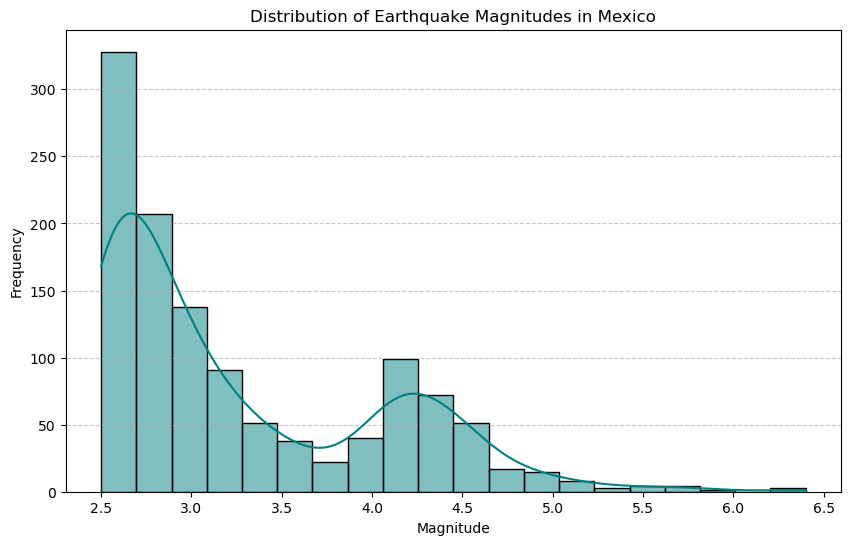

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed data
df = pd.read_csv('../data/processed/earthquakes_clean.csv')
df['time'] = pd.to_datetime(df['time'])

# Plotting the Distribution of Magnitudes
plt.figure(figsize=(10, 6))
sns.histplot(df['magnitude'], bins=20, kde=True, color='teal')
plt.title('Distribution of Earthquake Magnitudes in Mexico')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../outputs/figures/earthquake_distribution_magnitudes.png', bbox_inches='tight')
plt.show()

### 2️⃣ Earthquake Frequency Over Time

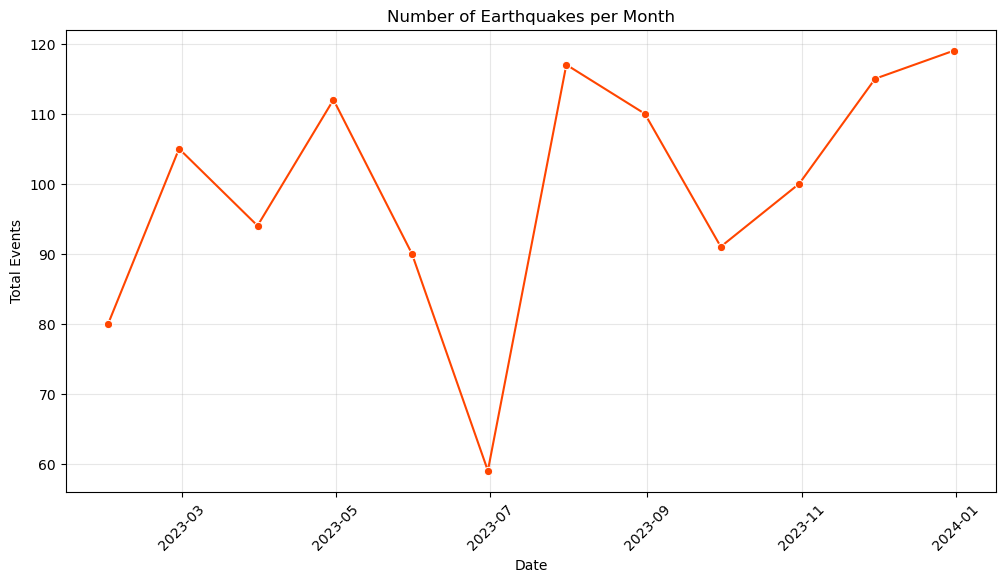

In [7]:
# Grouping by month
df_monthly = df.set_index('time').resample('ME').size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly, x='time', y='count', marker='o', color='orangered')
plt.title('Number of Earthquakes per Month')
plt.xlabel('Date')
plt.ylabel('Total Events')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/figures/earthquake_monthly_trend.png', bbox_inches='tight')
plt.show()

### 3️⃣ Top 10 Most Active Regions

**Question:** Which states or areas experience the most seismic activity?

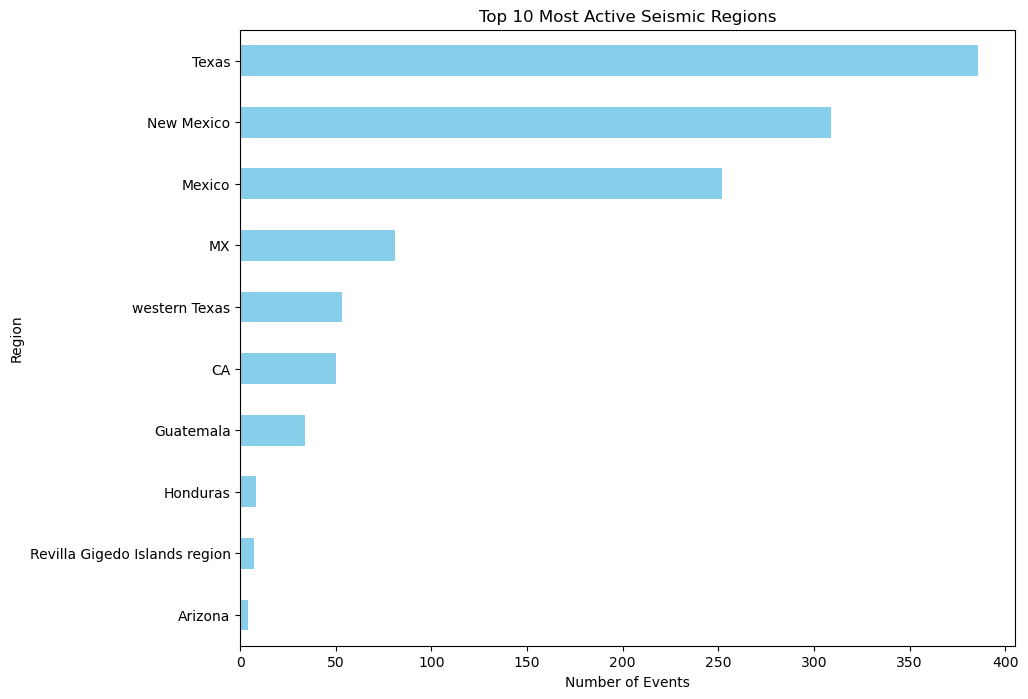

In [8]:
# Extracting the region from the 'place' column (usually after 'of')
df['region'] = df['place'].str.split(',').str[-1].str.strip()

top_regions = df['region'].value_counts().head(10)

plt.figure(figsize=(10, 8))
top_regions.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis() # Highest on top
plt.title('Top 10 Most Active Seismic Regions')
plt.xlabel('Number of Events')
plt.ylabel('Region')
plt.savefig('../outputs/figures/earthquake_top_regions.png', bbox_inches='tight')
plt.show()